In [ ]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as pltdata:image/svg+xml,%3Csvg%20width%3D%2220%22%20height%3D%2220%22%20fill%3D%22none%22%20xmlns%3D%22http%3A%2F%2Fwww.w3.org%2F2000%2Fsvg%22%3E%3Cpath%20d%3D%22M2.082%2010c0-3.731%200-5.597%201.16-6.757C4.4%202.084%206.266%202.084%209.998%202.084c3.732%200%205.598%200%206.757%201.16%201.16%201.159%201.16%203.025%201.16%206.757%200%203.732%200%205.598-1.16%206.757-1.16%201.16-3.025%201.16-6.757%201.16-3.732%200-5.598%200-6.758-1.16-1.159-1.16-1.159-3.025-1.159-6.757Z%22%20stroke%3D%22%230A4DFE%22%20stroke-width%3D%221.25%22%2F%3E%3Cpath%20d%3D%22M2.082%207.5h15.833%22%20stroke%3D%22%230A4DFE%22%20stroke-width%3D%221.25%22%20stroke-linejoin%3D%22round%22%2F%3E%3Cpath%20d%3D%22M5.832%205h.008M9.168%205h.007%22%20stroke%3D%22%230A4DFE%22%20stroke-width%3D%221.667%22%20stroke-linecap%3D%22round%22%20stroke-linejoin%3D%22round%22%2F%3E%3Cpath%20d%3D%22M10%2013.963h2.224M10%2011.262h5.224M7.262%207.547v9.678%22%20stroke%3D%22%230A4DFE%22%20stroke-width%3D%221.25%22%20stroke-linecap%3D%22round%22%20stroke-linejoin%3D%22round%22%2F%3E%3C%2Fsvg%3E
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from datetime import datetime
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

####Section 1: Data Loading and Initial Exploration

In [ ]:
# Loading Dataset
df = pd.read_csv('delhivery_data.csv')
df

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:57:20,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:31:18,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:11:18,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.7053,0.588235
144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 20:53:19,73.680667,158.0,98.0,111.2709,1.612245,17.0,27.0,18.8885,0.629630


####Section 2: Problem Statment and EDA


#####Problem Statement:
*Delhivery wants to understand and process the data from their logistics operations to:*

*1. Clean and manipulate raw data to extract useful features*

*2. Build intelligence for forecasting models*

*3. Optimize delhivery operations through data insights*

In [ ]:
# Shape of the dataset
df.shape

(144867, 24)

In [ ]:
#Information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [ ]:
# Missing values analysis
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


In [ ]:
# Statistical Summary
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [ ]:
# Covert categorical columns into categorical
categorical_columns = ['data', 'route_type', 'source_name', 'destination_name']
df[categorical_columns] = df[categorical_columns].astype('category')
df[categorical_columns].dtypes

,0
data,category
route_type,category
source_name,category
destination_name,category


#### Section 3: Visual Analysis

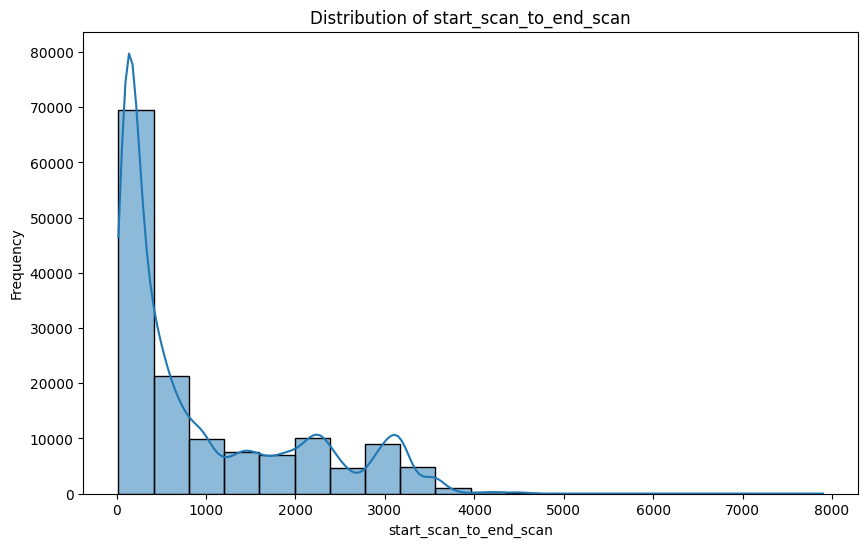

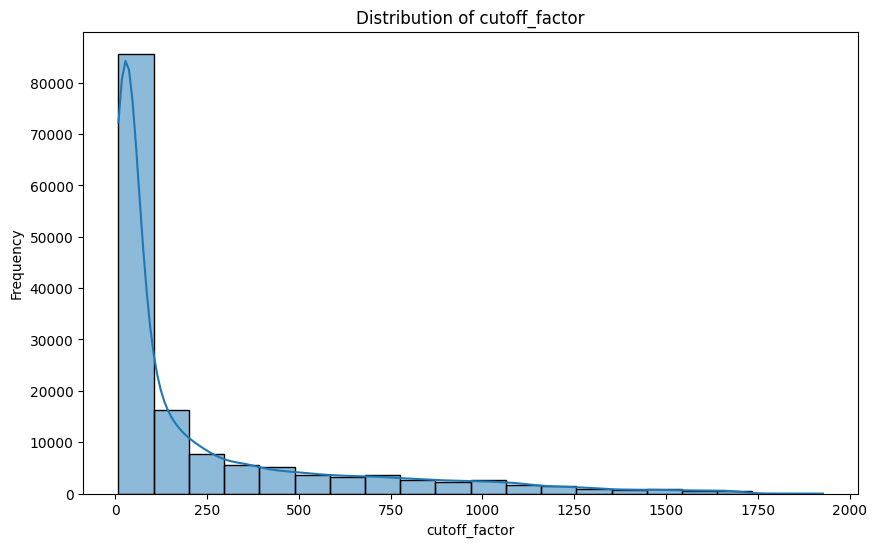

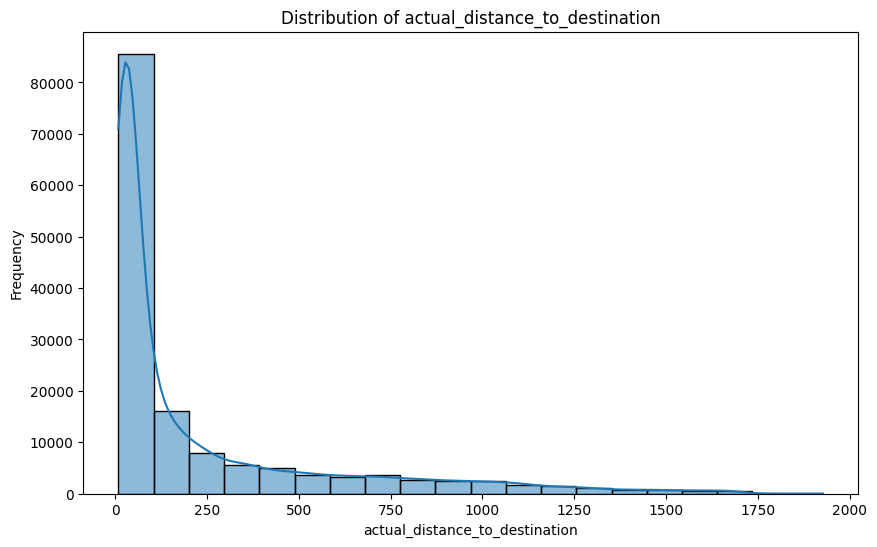

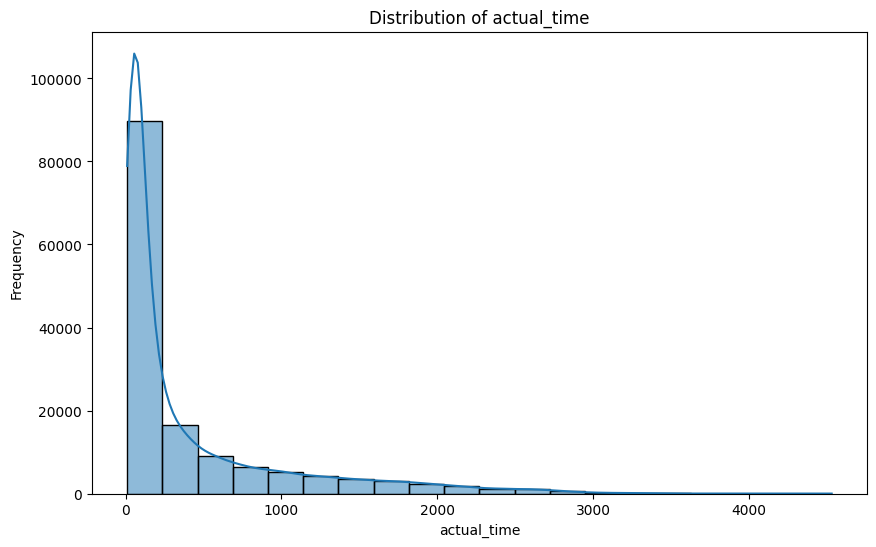

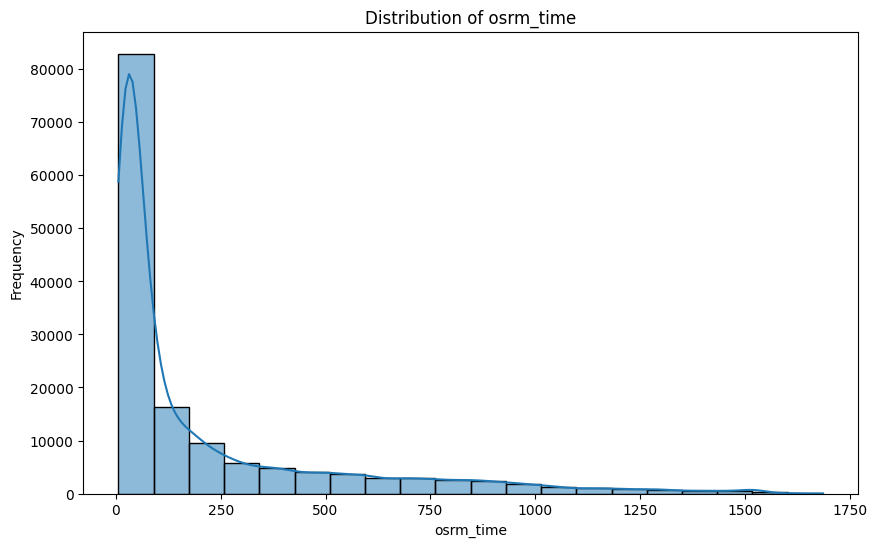

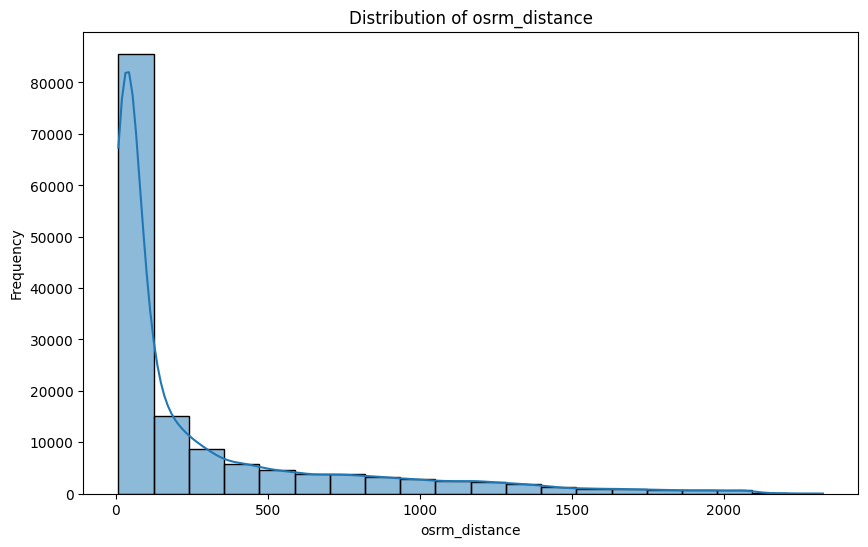

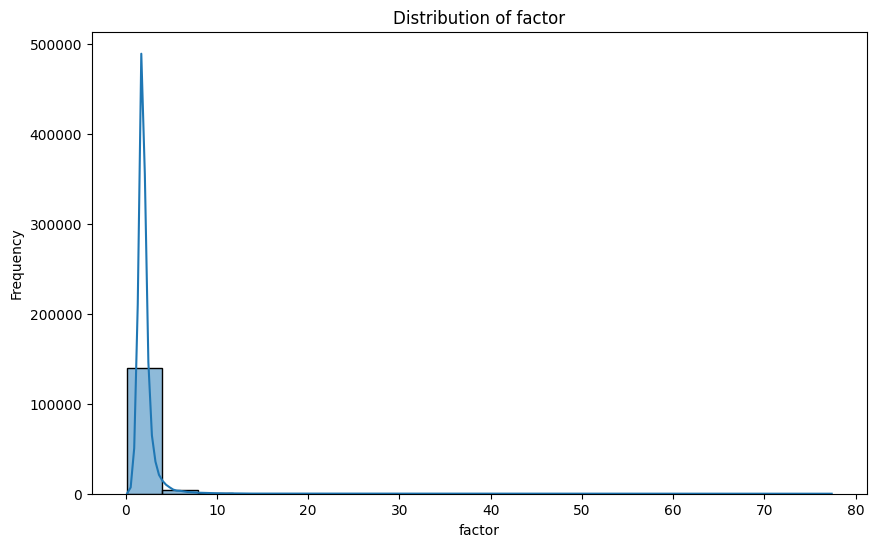

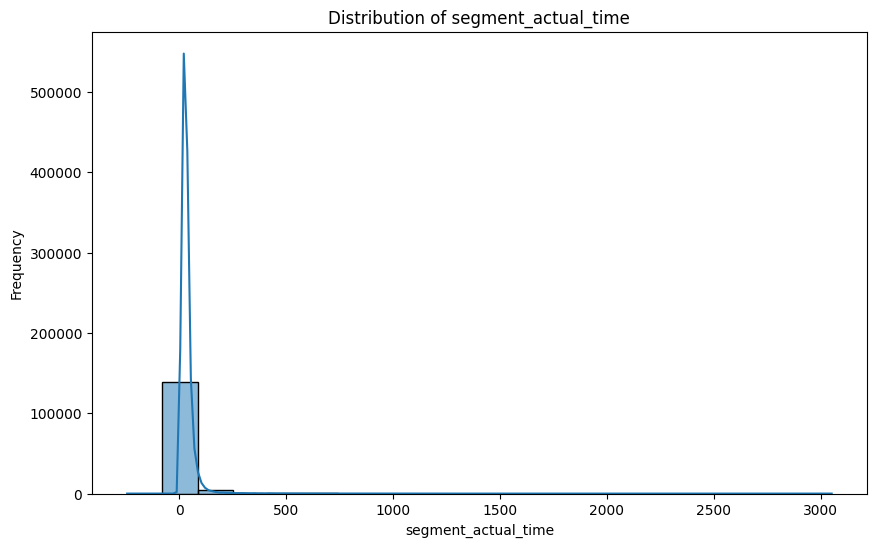

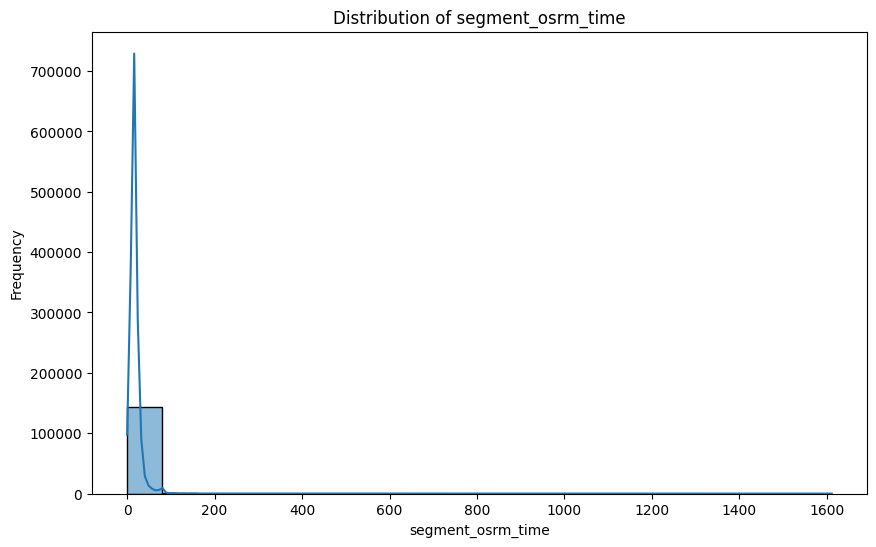

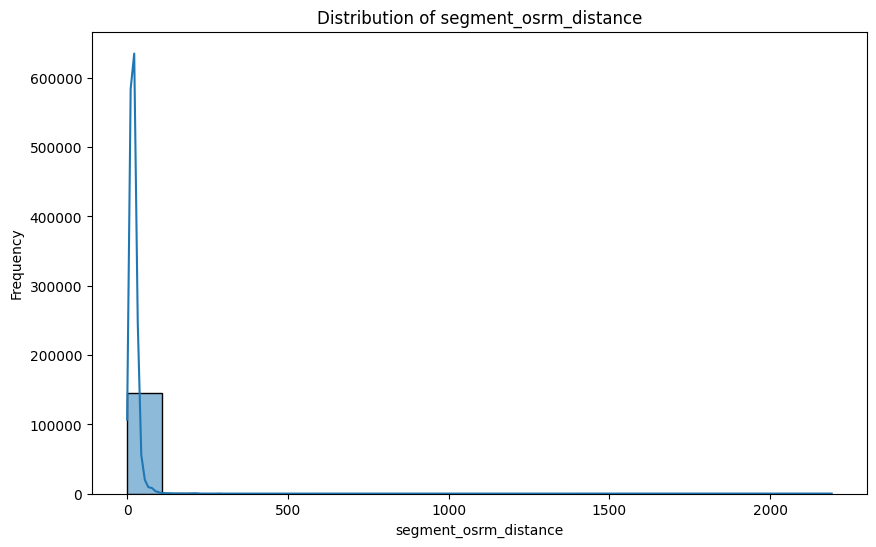

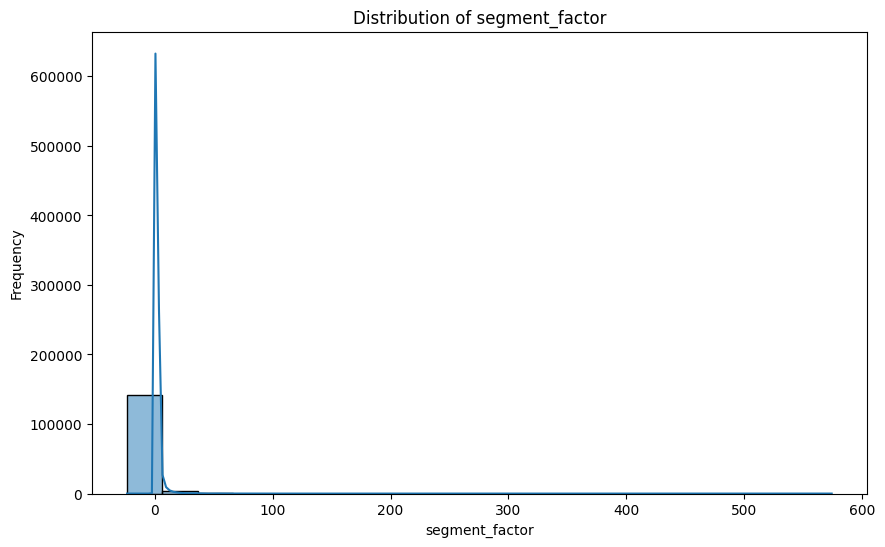

In [ ]:
#continuous variables
numerical_columns = ['start_scan_to_end_scan', 'cutoff_factor', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor']
for numerical in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[numerical], bins=20, kde=True)
    plt.title(f'Distribution of {numerical}')
    plt.xlabel(numerical)
    plt.ylabel('Frequency')
    plt.show()

#### Section 4: Feature Creation

In [ ]:
# Feature Creation

# Convert time columns to datetime objects
time_columns = ['trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
for col in time_columns:
    df[col] = pd.to_datetime(df[col], format='mixed')

# Create features based on time differences
df['trip_duration'] = (df['od_end_time'] - df['od_start_time']).dt.total_seconds() / 60  # in minutes
df['time_to_start'] = (df['od_start_time'] - df['trip_creation_time']).dt.total_seconds() / 60  # in minutes
df['time_to_cutoff'] = (df['cutoff_timestamp'] - df['od_start_time']).dt.total_seconds() / 60  # in minutes

# Create features based on ratios
df['distance_time_ratio'] = df['actual_distance_to_destination'] / df['actual_time']
df['osrm_distance_time_ratio'] = df['osrm_distance'] / df['osrm_time']
df['segment_distance_time_ratio'] = df['segment_osrm_distance'] / df['segment_osrm_time']

# Display the first few rows with new features
display(df.head())

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,trip_duration,time_to_start,time_to_cutoff,distance_time_ratio,osrm_distance_time_ratio,segment_distance_time_ratio
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,14.0,11.0,11.9653,1.272727,86.213637,45.932363,66.376357,0.745404,1.087755,1.087755
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,10.0,9.0,9.7590,1.111111,86.213637,45.932363,56.376357,0.789035,1.086215,1.084333
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,16.0,7.0,10.8152,2.285714,86.213637,45.932363,39.784783,0.690932,1.162125,1.545029
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,21.0,12.0,13.0224,1.750000,86.213637,45.932363,18.409690,0.582549,1.139050,1.085200
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,6.0,5.0,3.9153,1.200000,86.213637,45.932363,12.376357,0.579206,1.232230,0.783060


#### Section 5: Merging Rows and Aggregation

In [ ]:
# Aggregate data by trip_uuid
agg_functions = {
    'data': 'first',
    'route_schedule_uuid': 'first',
    'route_type': 'first',
    'source_center': 'first',
    'source_name': 'first',
    'destination_center': 'first',
    'destination_name': 'first',
    'trip_creation_time': 'first',
    'od_start_time': 'first',
    'od_end_time': 'first',
    'start_scan_to_end_scan': 'mean',
    'is_cutoff': 'first',
    'cutoff_factor': 'mean',
    'cutoff_timestamp': 'first',
    'actual_distance_to_destination': 'mean',
    'actual_time': 'mean',
    'osrm_time': 'mean',
    'osrm_distance': 'mean',
    'factor': 'mean',
    'segment_actual_time': 'mean',
    'segment_osrm_time': 'mean',
    'segment_osrm_distance': 'mean',
    'segment_factor': 'mean',
    'trip_duration': 'first',
    'time_to_start': 'first',
    'time_to_cutoff': 'first',
    'distance_time_ratio': 'mean',
    'osrm_distance_time_ratio': 'mean',
    'segment_distance_time_ratio': 'mean'
}

df_aggregated = df.groupby('trip_uuid').agg(agg_functions).reset_index()

# Display the first few rows of the aggregated dataframe
display(df_aggregated.head())

,trip_uuid,data,route_schedule_uuid,route_type,source_center,source_name,destination_center,destination_name,trip_creation_time,od_start_time,...,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,trip_duration,time_to_start,time_to_cutoff,distance_time_ratio,osrm_distance_time_ratio,segment_distance_time_ratio
0,trip-153671041653548748,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,2018-09-12 00:00:16.535741,...,39.692308,25.846154,33.858290,2.022887,999.505379,0.0,896.207738,0.594679,1.351776,1.379137
1,trip-153671042288605164,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 00:00:22.886430,...,15.666667,7.222222,9.354378,2.540564,122.779486,0.0,99.085226,0.628165,1.260677,1.322059
2,trip-153671043369099517,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 00:00:33.691250,2018-09-12 00:00:33.691250,...,37.168539,21.808989,28.598515,1.797082,3099.723591,0.0,2910.005146,0.617324,1.341385,1.369879
3,trip-153671046011330457,training,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,Mumbai Hub (Maharashtra),IND401104AAA,Mumbai_MiraRd_IP (Maharashtra),2018-09-12 00:01:00.113710,2018-09-12 00:01:00.113710,...,29.500000,8.000000,9.938300,3.849206,100.494935,0.0,72.931438,0.392387,1.320861,1.229797
4,trip-153671052974046625,training,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,Bellary_Dc (Karnataka),IND583201AAA,Hospet (Karnataka),2018-09-12 00:02:09.740725,2018-09-12 00:02:09.740725,...,48.571429,16.428571,20.970271,3.364728,152.012914,0.0,105.270988,0.468118,1.283489,1.289386


#### Section 6: Time and Distance Field Comparisions

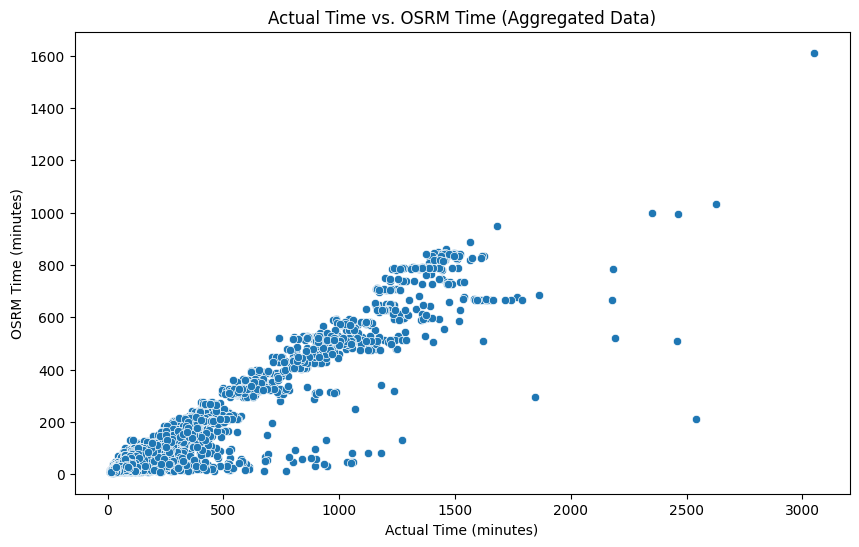

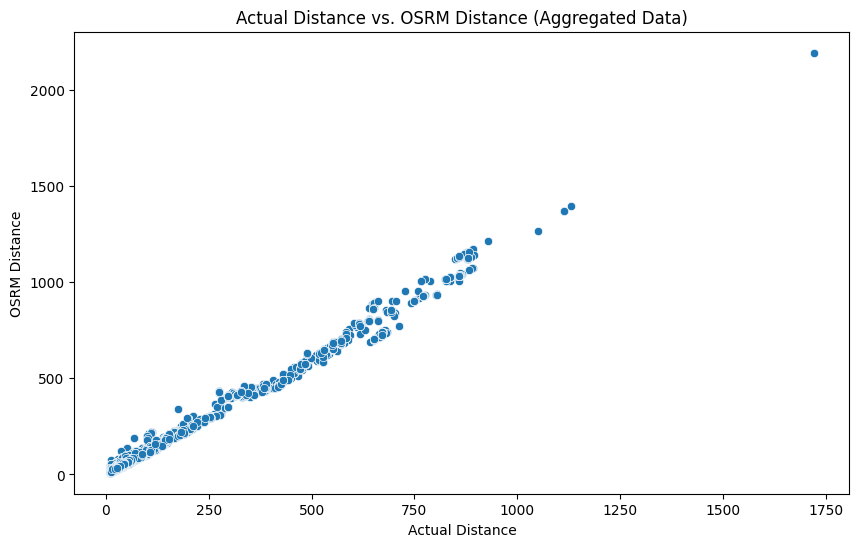


Correlation Matrix:


,actual_time,osrm_time,actual_distance_to_destination,osrm_distance
actual_time,1.000000,0.954087,0.952500,0.955457
osrm_time,0.954087,1.000000,0.994374,0.998250
actual_distance_to_destination,0.952500,0.994374,1.000000,0.997147
osrm_distance,0.955457,0.998250,0.997147,1.000000


In [ ]:
# Scatter plot of actual time vs. osrm time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='actual_time', y='osrm_time', data=df_aggregated)
plt.title('Actual Time vs. OSRM Time (Aggregated Data)')
plt.xlabel('Actual Time (minutes)')
plt.ylabel('OSRM Time (minutes)')
plt.show()

# Scatter plot of actual distance vs. osrm distance
plt.figure(figsize=(10, 6))
sns.scatterplot(x='actual_distance_to_destination', y='osrm_distance', data=df_aggregated)
plt.title('Actual Distance vs. OSRM Distance (Aggregated Data)')
plt.xlabel('Actual Distance')
plt.ylabel('OSRM Distance')
plt.show()

# Correlation matrix for time and distance features
time_distance_cols = ['actual_time', 'osrm_time', 'actual_distance_to_destination', 'osrm_distance']
correlation_matrix = df_aggregated[time_distance_cols].corr()
print("\nCorrelation Matrix:")
display(correlation_matrix)

#### Section 7: Hypothesis Testing and Analysis

In [ ]:
# Hypothesis Testing: Comparing Actual Time and OSRM Time
# Null Hypothesis (H0): There is no significant difference between the mean actual time and the mean OSRM time.
# Alternative Hypothesis (H1): There is a significant difference between the mean actual time and the mean OSRM time.

# Perform independent samples t-test
t_statistic, p_value = ttest_ind(df_aggregated['actual_time'], df_aggregated['osrm_time'])

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nReject the null hypothesis: There is a significant difference between the mean actual time and the mean OSRM time.")
else:
    print("\nFail to reject the null hypothesis: There is no significant difference between the mean actual time and the mean OSRM time.")

T-statistic: 34.9119
P-value: 0.0000

Reject the null hypothesis: There is a significant difference between the mean actual time and the mean OSRM time.


#### Section 8: Missing Values and Outlier Treatment

In [ ]:
# Handle missing values
print("Before treatment:")
print(df.isnull().sum().sort_values(ascending=False))

# Fill missing values with appropriate strategies
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Fill numeric missing values with median
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Filled {col} missing values with median: {median_value:.2f}")

# Fill categorical missing values with mode
for col in categorical_columns:
    if col in df.columns and df[col].isnull().sum() > 0:
        mode_value = df[col].mode().iloc[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_value, inplace=True)
        print(f"Filled {col} missing values with mode: {mode_value}")

print("\nAfter treatment:")
print(df.isnull().sum().sum(), "total missing values remaining")

Before treatment:
segment_distance_time_ratio       1536
source_name                        293
destination_name                   261
route_schedule_uuid                  0
data                                 0
route_type                           0
source_center                        0
trip_uuid                            0
destination_center                   0
od_start_time                        0
od_end_time                          0
start_scan_to_end_scan               0
is_cutoff                            0
trip_creation_time                   0
cutoff_factor                        0
cutoff_timestamp                     0
actual_time                          0
actual_distance_to_destination       0
osrm_distance                        0
factor                               0
segment_actual_time                  0
osrm_time                            0
segment_osrm_time                    0
segment_osrm_distance                0
trip_duration                        0
segment

#### Section 9: Outlier Detection and Treatment

actual_time: 16633 outliers detected


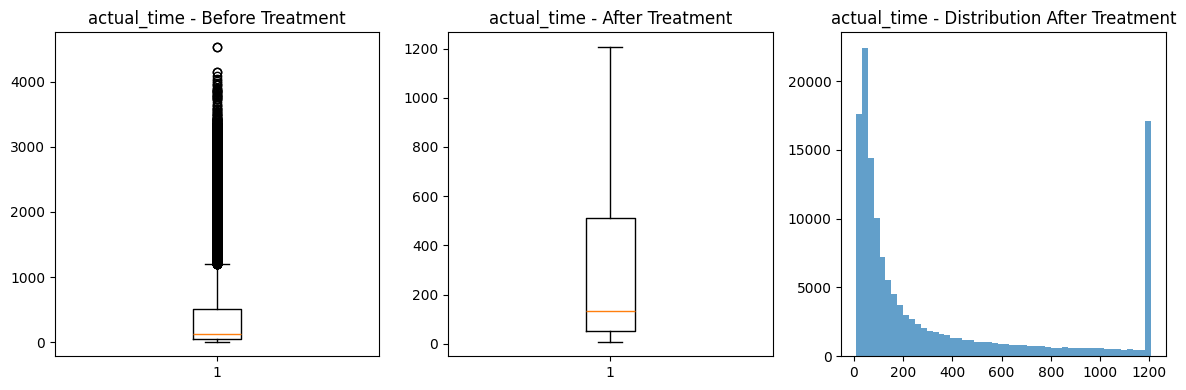

osrm_time: 17603 outliers detected


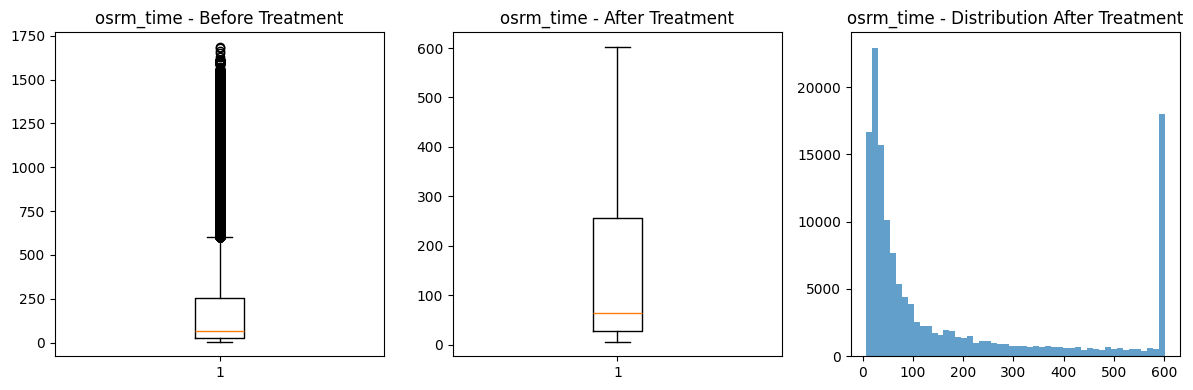

osrm_distance: 17816 outliers detected


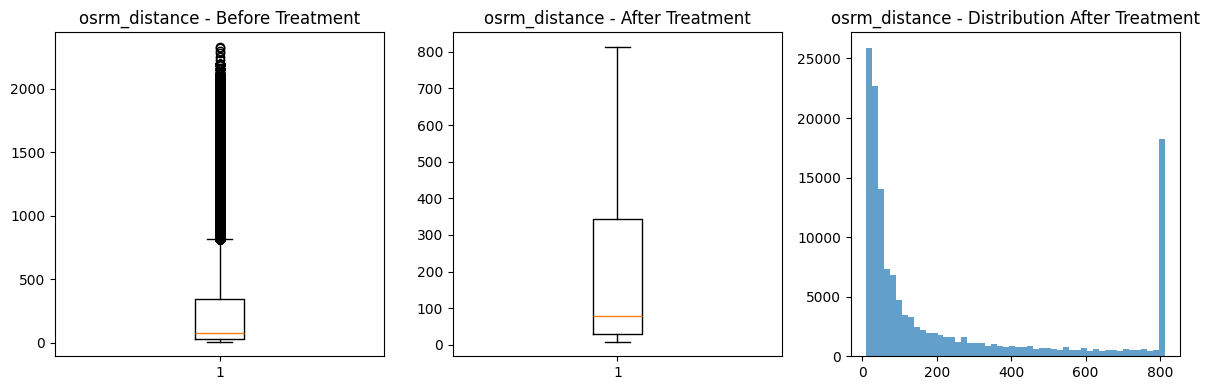

segment_actual_time: 9298 outliers detected


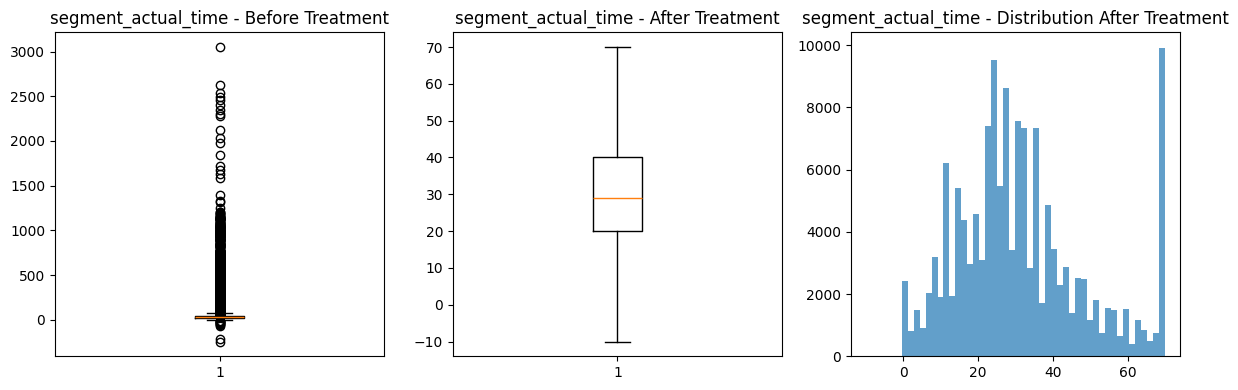

segment_osrm_time: 6378 outliers detected


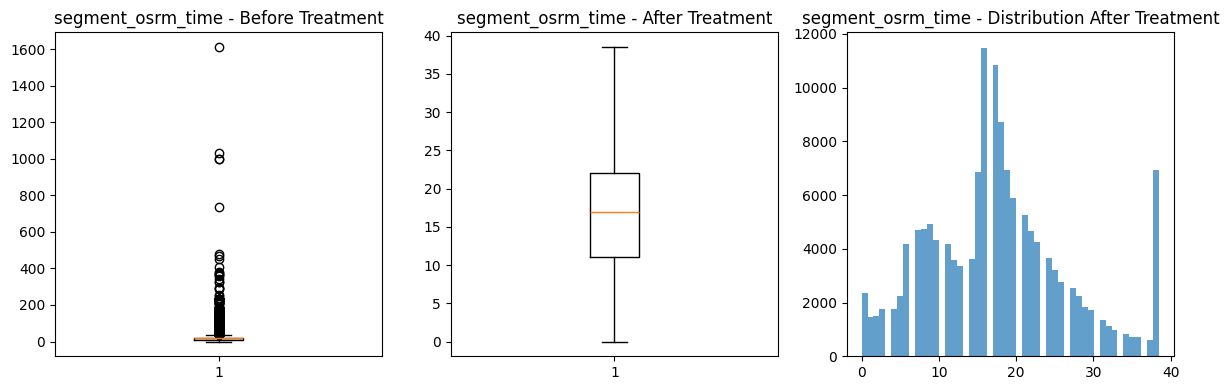

segment_osrm_distance: 4315 outliers detected


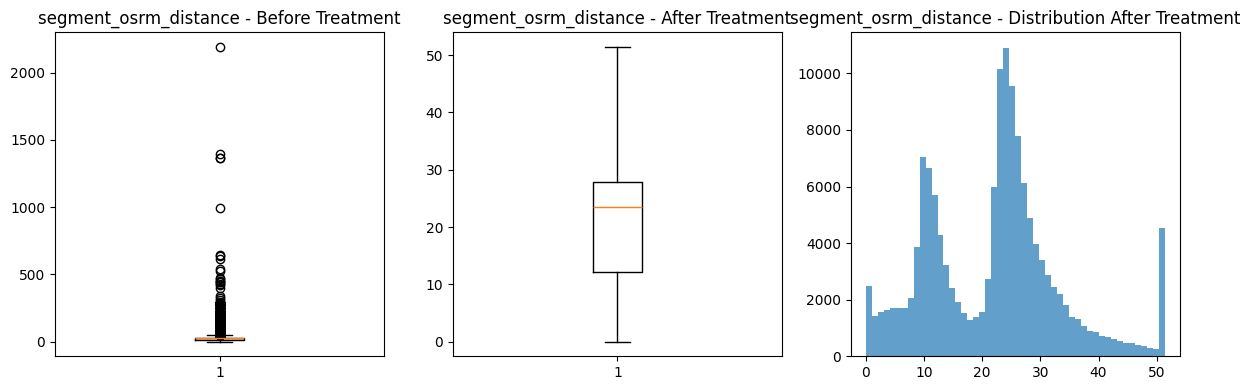

actual_distance_to_destination: 17992 outliers detected


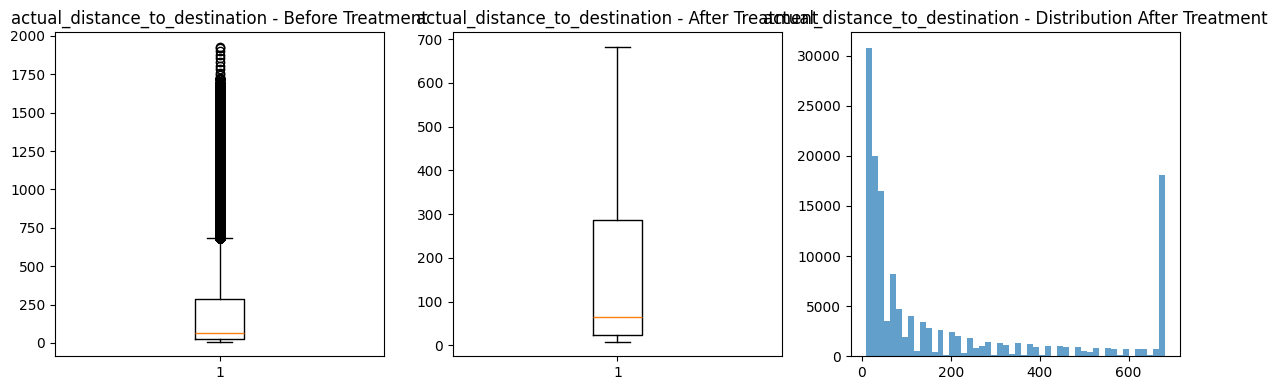

Outlier treatment completed!


In [ ]:
def detect_and_treat_outliers(df, column, method='iqr'):
    """Detect and treat outliers using IQR method"""
    if column not in df.columns:
        return df

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = len(df[(df[column] < lower_bound) | (df[column] > upper_bound)])

    print(f"{column}: {outliers_count} outliers detected")

    # Visualize outliers
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.boxplot(df[column].dropna())
    plt.title(f'{column} - Before Treatment')

    # Cap outliers instead of removing them
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])

    plt.subplot(1, 3, 2)
    plt.boxplot(df[column].dropna())
    plt.title(f'{column} - After Treatment')

    plt.subplot(1, 3, 3)
    plt.hist(df[column].dropna(), bins=50, alpha=0.7)
    plt.title(f'{column} - Distribution After Treatment')

    plt.tight_layout()
    plt.show()

    return df

# Treat outliers in numeric columns
outlier_columns = ['actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time',
                   'segment_osrm_time', 'segment_osrm_distance', 'actual_distance_to_destination']

for col in outlier_columns:
    if col in df.columns:
        df = detect_and_treat_outliers(df, col)

print("Outlier treatment completed!")

#### Section 10: Categorical Variable Encoding

In [ ]:
# One-hot encoding for categorical variables
categorical_cols_to_encode = ['route_type', 'dest_state', 'source_state', 'data']

print("Performing one-hot encoding for categorical variables...")

for col in categorical_cols_to_encode:
    if col in df.columns:
        # Get dummies and add to dataframe
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        print(f"One-hot encoded {col}: {len(dummies.columns)} new columns created")

# Remove original categorical columns that were encoded
for col in categorical_cols_to_encode:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print(f"\nDataset shape after encoding: {df.shape}")
print("One-hot encoding completed!")

Performing one-hot encoding for categorical variables...
One-hot encoded route_type: 1 new columns created
One-hot encoded data: 1 new columns created

Dataset shape after encoding: (144867, 30)
One-hot encoding completed!


#### Section 11: Normalization / Standardization

In [ ]:
# Select numeric columns for scaling
numeric_cols_for_scaling = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns and categorical encoded columns from scaling
id_cols = ['trip_uuid', 'source_center', 'destination_cente', 'creation_year', 'creation_month', 'creation_day']
numeric_cols_for_scaling = [col for col in numeric_cols_for_scaling if col not in id_cols]

print(f"Columns to be scaled: {numeric_cols_for_scaling}")

# Replace infinite values with a large number
df.replace([np.inf, -np.inf], 1e9, inplace=True)

# Apply StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()

if numeric_cols_for_scaling:
    df_scaled[numeric_cols_for_scaling] = scaler.fit_transform(df[numeric_cols_for_scaling])
    print("StandardScaler applied successfully!")

    # Show before and after statistics
    print("\nBefore scaling (sample statistics):")
    print(df[numeric_cols_for_scaling[:5]].describe())

    print("\nAfter scaling (sample statistics):")
    print(df_scaled[numeric_cols_for_scaling[:5]].describe())

Columns to be scaled: ['start_scan_to_end_scan', 'cutoff_factor', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'trip_duration', 'time_to_start', 'time_to_cutoff', 'distance_time_ratio', 'osrm_distance_time_ratio', 'segment_distance_time_ratio']
StandardScaler applied successfully!

Before scaling (sample statistics):
       start_scan_to_end_scan  cutoff_factor  actual_distance_to_destination  \
count           144867.000000  144867.000000                   144867.000000   
mean               961.262986     232.926567                      191.212020   
std               1037.012769     344.755577                      235.284651   
min                 20.000000       9.000000                        9.000045   
25%                161.000000      22.000000                       23.355874   
50%                449.000000      66.000000                       66.

#### Section 12: Business Insights

In [ ]:
# 1. Orders by state analysis
if 'source_state' in df.columns:
    print("1. ORDER ANALYSIS BY SOURCE STATE:")
    source_state_counts = df['source_state'].value_counts().head(10)
    print(source_state_counts)

    plt.figure(figsize=(12, 6))
    source_state_counts.plot(kind='bar')
    plt.title('Top 10 Source States by Order Volume')
    plt.xlabel('State')
    plt.ylabel('Number of Orders')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 2. Route type analysis
if 'route_type' in df.columns:
    print("\n2. ROUTE TYPE ANALYSIS:")
    route_analysis = df.groupby('route_type').agg({
        'actual_distance_to_destination': 'mean',
        'actual_time': 'mean',
        'trip_uuid': 'count'
    }).round(2)
    route_analysis.columns = ['Avg_Distance_km', 'Avg_Time_hours', 'Order_Count']
    print(route_analysis)

# 3. Corridor analysis
if all(col in df.columns for col in ['source_state', 'dest_state']):
    print("\n3. BUSIEST CORRIDORS ANALYSIS:")
    df['corridor'] = df['source_state'] + ' -> ' + df['dest_state']
    corridor_analysis = df.groupby('corridor').agg({
        'actual_distance_to_destination': 'mean',
        'actual_time': 'mean',
        'trip_uuid': 'count'
    }).round(2)
    corridor_analysis.columns = ['Avg_Distance_km', 'Avg_Time_hours', 'Order_Count']
    top_corridors = corridor_analysis.sort_values('Order_Count', ascending=False).head(10)
    print(top_corridors)

# 4. Time-based patterns
if 'creation_month' in df.columns:
    print("\n4. SEASONAL PATTERNS:")
    monthly_orders = df.groupby('creation_month')['trip_uuid'].count()
    print("Orders by month:")
    print(monthly_orders)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    monthly_orders.plot(kind='bar')
    plt.title('Orders by Month')
    plt.xlabel('Month')
    plt.ylabel('Number of Orders')

    if 'creation_dayofweek' in df.columns:
        plt.subplot(1, 2, 2)
        daily_orders = df.groupby('creation_dayofweek')['trip_uuid'].count()
        daily_orders.plot(kind='bar')
        plt.title('Orders by Day of Week (0=Monday)')
        plt.xlabel('Day of Week')
        plt.ylabel('Number of Orders')

    plt.tight_layout()
    plt.show()

# 5. Delivery efficiency analysis
print("\n5. DELIVERY EFFICIENCY ANALYSIS:")
if all(col in df.columns for col in ['actual_time', 'osrm_time']):
    df['time_efficiency'] = df['osrm_time'] / df['actual_time']
    efficiency_stats = df['time_efficiency'].describe()
    print("Time Efficiency Statistics (OSRM/Actual):")
    print(efficiency_stats)


5. DELIVERY EFFICIENCY ANALYSIS:
Time Efficiency Statistics (OSRM/Actual):
count    144867.000000
mean          0.545789
std           0.186019
min           0.013072
25%           0.460317
50%           0.520000
75%           0.620482
max           6.944444
Name: time_efficiency, dtype: float64


#### Section 13: Recommendations

#### 1.**Route Optimization (Making Deliveries Faster):**

Focus on improving long-distance routes since they carry more shipments.

Make routes in busy city areas more flexible to adjust in real time.

Use software (like OSRM) to predict delivery times and set expectations.

#### 2.**Capacity Planning (Managing Resources):**

Prepare for busier periods during certain months (like holidays) when more shipments happen.

Plan how many workers are needed based on days of the week (e.g., weekends might be busier).

Focus extra resources on the routes that handle the most deliveries.

#### 3.**Performance Monitoring (Keep Track of How Well We’re Doing):**

Set up alerts to warn us if deliveries are taking much longer than predicted (e.g., more than 20% extra time).

Keep an eye on routes that always seem to be slow.

Break down performance into smaller sections of the route to find where problems happen.

#### 4.**Operational Improvements (Making Work Better):**

Standardize (make the same) processes in states or areas with a lot of deliveries.

Use smart tech to predict when vehicles need maintenance, especially on popular routes.

Have backup plans for routes that are hard to predict (like ones with weather or traffic issues).

#### 5.**Customer Experience (Making Customers Happy):**

Give more accurate delivery time estimates based on past performance of the route.

Communicate early if a shipment is delayed, so customers aren’t surprised.

Offer faster services for customers who need deliveries urgently.

#### 6.**Data Quality (Making Sure Information Is Accurate):**

Check data early to avoid missing or wrong information.

Make sure locations are named consistently across all systems (no confusion).

Regularly check the time data for mistakes to ensure accuracy.

#### 7.**Strategic Decisions (Big Picture Thinking):**

Think about opening new hubs (warehouses or centers) in areas with high demand but no service yet.

Look into working with partners for delivering in hard-to-reach locations.

Invest in technology to track shipments in real-time and improve efficiency.